<a href="https://colab.research.google.com/github/Priya-git2005/Gen-AI_CTTC/blob/main/Gen_AI_(Day_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
ins = pd.read_csv("/content/Medical Insurance Dataset.csv")
ins

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
3033,32,female,17.765,2,yes,northwest,32734.18630
3034,38,male,34.700,2,no,southwest,6082.40500
3035,59,female,26.505,0,no,northeast,12815.44495
3036,61,female,22.040,0,no,northeast,13616.35860


In [2]:
#null value check
ins.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [3]:
ins.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


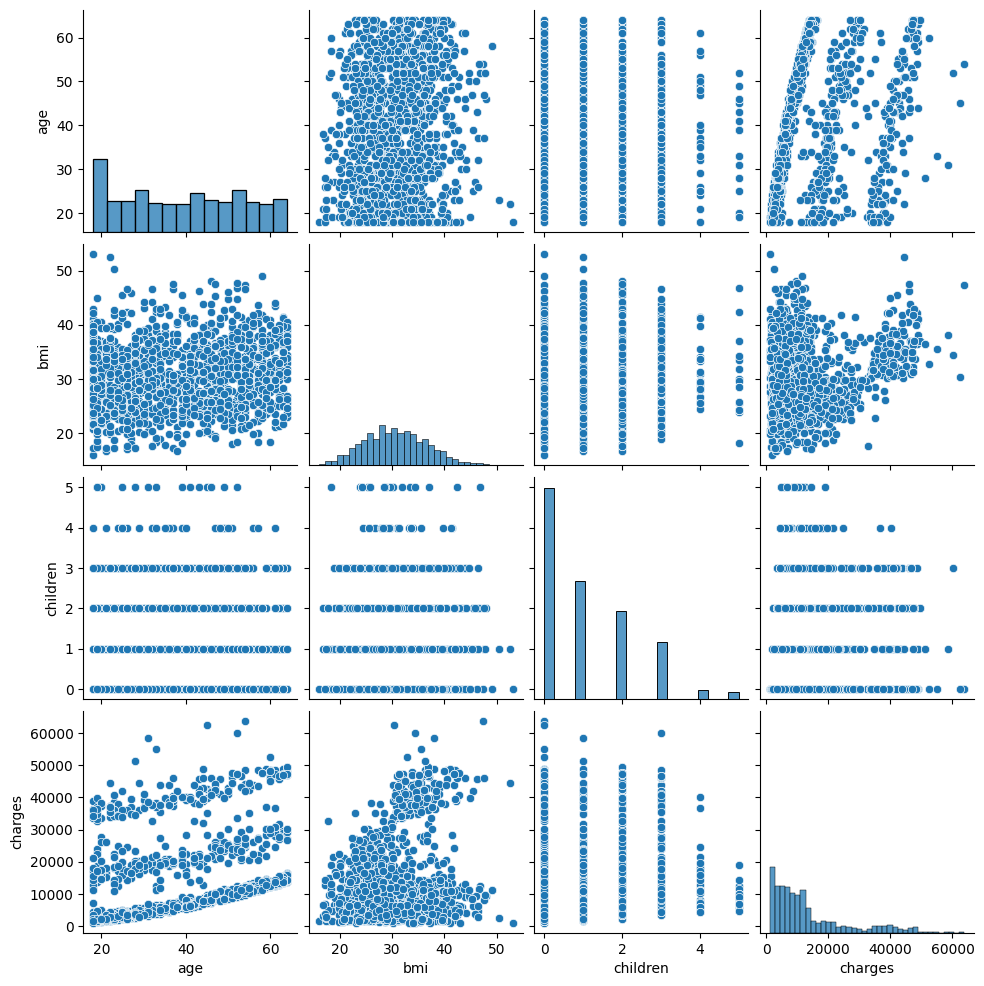

In [4]:
import seaborn as sns
sns.pairplot(ins)

In [5]:
ins.sex.unique()

array(['female', 'male'], dtype=object)

In [6]:
#encoding con str-> int

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [7]:
#encoding apply
for col in ins.columns:
  if ins[col].dtype == 'object':
    ins[col]= le.fit_transform(ins[col])

In [8]:
ins.sex.unique()

array([0, 1])

In [9]:
ins.dtypes

,0
age,int64
sex,int64
bmi,float64
children,int64
smoker,int64
region,int64
charges,float64


In [10]:
#ip op creation
ip = ins.drop('charges',axis=1)
op = ins.charges

In [11]:
ip

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1
...,...,...,...,...,...,...
3033,32,0,17.765,2,1,1
3034,38,1,34.700,2,0,3
3035,59,0,26.505,0,0,0
3036,61,0,22.040,0,0,0


In [12]:
op

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
3033,32734.18630
3034,6082.40500
3035,12815.44495
3036,13616.35860


In [13]:
#train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(ip,op,test_size=0.20)

In [14]:
print(x_train.shape) #main trg data
print(x_test.shape) #main testing data

(2430, 6)
(608, 6)


In [15]:
x_train

,age,sex,bmi,children,smoker,region
2740,28,1,24.300,5,0,3
1226,38,1,16.815,2,0,0
280,40,0,28.120,1,1,0
1851,30,0,28.380,1,1,2
973,19,0,40.500,0,0,3
...,...,...,...,...,...,...
412,26,0,17.195,2,1,0
319,32,1,37.335,1,0,0
2643,54,0,27.645,1,0,1
2791,18,0,35.625,0,0,0


In [16]:
#scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [17]:
#main trg or main testing
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [18]:
x_test

array([[ 0.35447347, -1.02329763,  1.17616232, -0.85750446,  1.89896303,
         0.37912903],
       [-1.12506798,  0.97723279,  3.14380813, -0.03903866, -0.52660319,
         0.37912903],
       [ 0.49538218, -1.02329763, -1.71621313,  0.77942713, -0.52660319,
        -0.52483352],
       ...,
       [-0.91370492,  0.97723279,  2.52891881, -0.03903866, -0.52660319,
         0.37912903],
       [ 0.56583654, -1.02329763, -1.13326612, -0.03903866, -0.52660319,
         1.28309159],
       [-0.91370492, -1.02329763, -0.19416244, -0.03903866, -0.52660319,
         0.37912903]])

In [19]:
#mode pkgs
import keras
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [20]:
model = Sequential()
#input
model.add(Dense(40,input_dim=6,activation='linear'))
#hidden
model.add(Dense(60,activation='linear'))
model.add(Dense(65,activation='linear'))
#out
model.add(Dense(1,activation='linear'))
#compile
model.compile(Adam(learning_rate=0.01),loss='mae')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.fit(x_train,y_train, validation_data=(x_test,y_test),epochs=20)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 9226.1680 - val_loss: 3582.7446
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3539.3662 - val_loss: 3603.7988
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3543.1404 - val_loss: 3526.8743
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3542.4443 - val_loss: 3505.5576
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3516.8625 - val_loss: 3482.9392
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3558.2205 - val_loss: 3576.8474
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3555.7041 - val_loss: 3569.9656
Epoch 8/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3547.6560 - val_loss: 3572.8108
Epoch 9/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3514.0481 - val_loss: 3509.9485
Epoch 10/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3498.1848 - val_loss: 3614.1670
Epoch 11/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3485.5083 - val_loss: 3495.1985
Epoch 1

In [22]:
model.evaluate(x_test,y_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3498.6479 


3498.64794921875